# Artist Modeling

This model will be fundamentally the same as the style model, but instead of classifying user art as a particular style, we will classify the art as resembling a particular artist's work.

In [25]:
import torch
import json
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Load splits
train_df = pd.read_csv("best-artworks-of-all-time/train.csv")
val_df   = pd.read_csv("best-artworks-of-all-time/val.csv")
test_df  = pd.read_csv("best-artworks-of-all-time/test.csv")

In [26]:
# set up reproducibility
import random
import numpy as np
import os

# reproducibility seed
SEED = 42

# python random
random.seed(SEED)

# numpy
np.random.seed(SEED)

# pytorch CPU
torch.manual_seed(SEED)

# pytorch CUDA
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# optional for newer pytorch versions
torch.use_deterministic_algorithms(True)

# python hash seed
os.environ["PYTHONHASHSEED"] = str(SEED)

In [27]:
# load artist label mapping
import json

with open("data/artist_labels.json", "r") as f:
    artist_labels = json.load(f)
idx_to_artist = {i: a for a, i in artist_labels.items()}
print(artist_labels)

{'Albrecht Dürer': 0, 'Alfred Sisley': 1, 'Amedeo Modigliani': 2, 'Andrei Rublev': 3, 'Andy Warhol': 4, 'Camille Pissarro': 5, 'Caravaggio': 6, 'Claude Monet': 7, 'Diego Rivera': 8, 'Diego Velazquez': 9, 'Edgar Degas': 10, 'Edouard Manet': 11, 'Edvard Munch': 12, 'El Greco': 13, 'Eugene Delacroix': 14, 'Francisco Goya': 15, 'Frida Kahlo': 16, 'Georges Seurat': 17, 'Giotto di Bondone': 18, 'Gustav Klimt': 19, 'Gustave Courbet': 20, 'Henri Matisse': 21, 'Henri Rousseau': 22, 'Henri de Toulouse-Lautrec': 23, 'Hieronymus Bosch': 24, 'Jackson Pollock': 25, 'Jan van Eyck': 26, 'Joan Miro': 27, 'Kazimir Malevich': 28, 'Leonardo da Vinci': 29, 'Marc Chagall': 30, 'Michelangelo': 31, 'Mikhail Vrubel': 32, 'Pablo Picasso': 33, 'Paul Cezanne': 34, 'Paul Gauguin': 35, 'Paul Klee': 36, 'Peter Paul Rubens': 37, 'Pierre-Auguste Renoir': 38, 'Piet Mondrian': 39, 'Pieter Bruegel': 40, 'Raphael': 41, 'Rembrandt': 42, 'Rene Magritte': 43, 'Salvador Dali': 44, 'Sandro Botticelli': 45, 'Titian': 46, 'Vasil

In [28]:
# running on gpu macbook apple silicon
device = torch.device("mps")
print(f"Using device: {device}")

Using device: mps


In [29]:
# image transformations (same as style modeling)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# use the artist labels rather than style labels for classification
class ArtDataset(Dataset):
    def __init__(self, dataframe, artist_labels, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.artist_labels = artist_labels
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = self.artist_labels[row["artist"]]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = ArtDataset(train_df, artist_labels, transform=train_transforms)
val_dataset   = ArtDataset(val_df, artist_labels, transform=val_transforms)
test_dataset  = ArtDataset(test_df, artist_labels, transform=val_transforms)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")
print(f"Test dataset size:  {len(test_dataset)}")

Train dataset size: 5912
Val dataset size:   1267
Test dataset size:  1267


In [30]:
g = torch.Generator()
g.manual_seed(SEED)

# Weighted sampler to handle class imbalance (some artists had way more paintings than others in the dataset)
class_counts = train_df["artist"].map(train_df["artist"].value_counts()).values
sample_weights = torch.tensor(1.0 / class_counts, dtype=torch.float)

sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=g # reproducibility
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,   num_workers=0)

In [31]:
# check
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")        
print(f"Dtype: {images.dtype}")              
print(f"Label sample: {[idx_to_artist[l.item()] for l in labels[:8]]}")

Batch shape: torch.Size([32, 3, 224, 224])
Dtype: torch.float32
Label sample: ['Pieter Bruegel', 'Eugene Delacroix', 'Paul Gauguin', 'Gustav Klimt', 'Pablo Picasso', 'Vasiliy Kandinskiy', 'William Turner', 'Georges Seurat']


## Efficient Net Set Up for Artist Model

In [32]:
import timm
import torch.nn as nn

class ArtistClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load pretrained EfficientNet-B0 with no classification head
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        
        # Get the output feature size from the backbone
        num_features = self.backbone.num_features  # 1280 for EfficientNet-B0
        
        # Custom classification head
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# we have a different number of classes for artist classification than style classification, so we need to re-instantiate the model with the correct output size
num_classes = len(artist_labels) # should be 50 artists
model = ArtistClassifier(num_classes=num_classes).to(device)

print(f"Number of classes: {num_classes}")
print(f"Model output size: {num_classes}")
print(f"Backbone output features: {model.backbone.num_features}")

Number of classes: 50
Model output size: 50
Backbone output features: 1280


Define loss, optimizer, and criterion. Very similar to the style model

In [33]:
import torch.optim as optim

# Loss — weighted to further penalize mistakes on low freq artists
class_counts_tensor = torch.tensor(
    [train_df["artist"].value_counts()[list(artist_labels.keys())[list(artist_labels.values()).index(i)]] for i in range(num_classes)],
    dtype=torch.float
)
class_weights = (1.0 / class_counts_tensor).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler — reduces LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

print("Criterion, optimizer, and scheduler ready")

Criterion, optimizer, and scheduler ready


### Training the model

In [34]:
# Training loop
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

# val loop (no backprop, just evaluation)
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

In [35]:
# History tracking
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  []
}

# Early stopping config stop if no improvement for 3 epochs
EARLY_STOPPING_PATIENCE = 3   
best_val_loss = float("inf")
epochs_no_improve = 0
best_epoch = 0

NUM_EPOCHS = 20  

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc     = val_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    # Record metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} | "
          f"LR: {current_lr:.2e}")

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "artifacts/best_artist_model.pt") # save best model weights into artifacts directory, don't overwrite style model weights if they exist
        print(f"  ✓ Saved best model")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs")

    # Early stopping check
    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\n Early stopping triggered at epoch {epoch+1}")
        print(f"  Best model was epoch {best_epoch} with val loss {best_val_loss:.4f}")
        break

print("\nTraining complete")

Epoch 01/20 | Train Loss: 3.0184 | Train Acc: 0.148 | Val Loss: 3.1824 | Val Acc: 0.099 | LR: 1.00e-04
  ✓ Saved best model
Epoch 02/20 | Train Loss: 1.7414 | Train Acc: 0.361 | Val Loss: 2.2392 | Val Acc: 0.228 | LR: 1.00e-04
  ✓ Saved best model
Epoch 03/20 | Train Loss: 1.0234 | Train Acc: 0.547 | Val Loss: 1.6613 | Val Acc: 0.346 | LR: 1.00e-04
  ✓ Saved best model
Epoch 04/20 | Train Loss: 0.6282 | Train Acc: 0.671 | Val Loss: 1.3746 | Val Acc: 0.436 | LR: 1.00e-04
  ✓ Saved best model
Epoch 05/20 | Train Loss: 0.4439 | Train Acc: 0.750 | Val Loss: 1.2290 | Val Acc: 0.504 | LR: 1.00e-04
  ✓ Saved best model
Epoch 06/20 | Train Loss: 0.3083 | Train Acc: 0.801 | Val Loss: 1.2009 | Val Acc: 0.527 | LR: 1.00e-04
  ✓ Saved best model
Epoch 07/20 | Train Loss: 0.2385 | Train Acc: 0.842 | Val Loss: 1.1524 | Val Acc: 0.561 | LR: 1.00e-04
  ✓ Saved best model
Epoch 08/20 | Train Loss: 0.1892 | Train Acc: 0.864 | Val Loss: 1.0987 | Val Acc: 0.576 | LR: 1.00e-04
  ✓ Saved best model
Epoch 09

### Plot Results

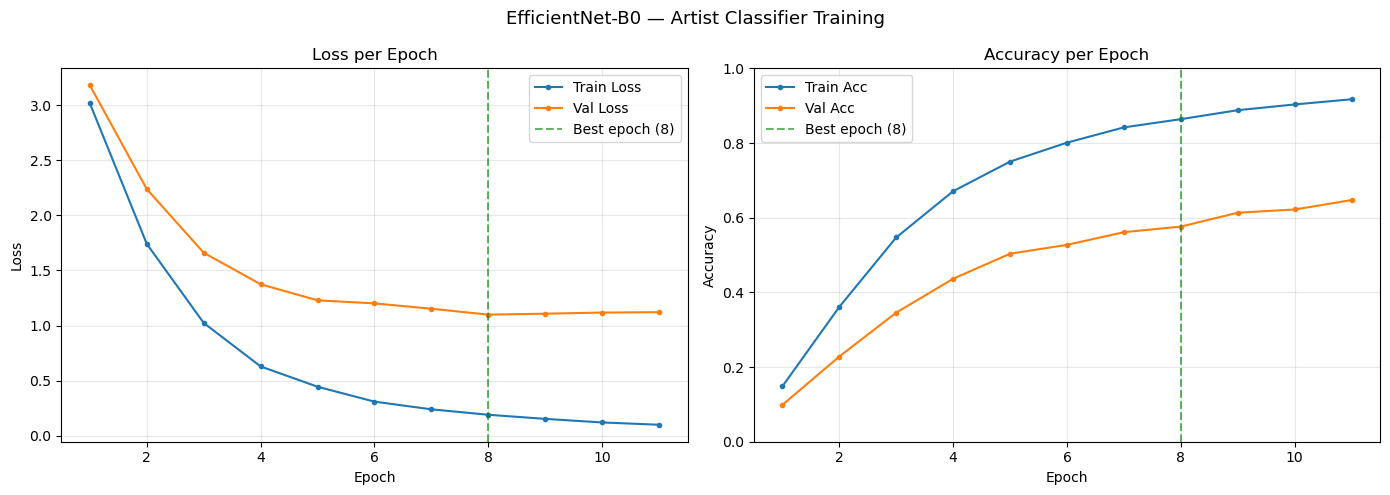

In [36]:
import matplotlib.pyplot as plt
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_ran, history["train_loss"], label="Train Loss", marker="o", markersize=3)
ax1.plot(epochs_ran, history["val_loss"],   label="Val Loss",   marker="o", markersize=3)
ax1.axvline(x=best_epoch, color="green", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_ran, history["train_acc"], label="Train Acc", marker="o", markersize=3)
ax2.plot(epochs_ran, history["val_acc"],   label="Val Acc",   marker="o", markersize=3)
ax2.axvline(x=best_epoch, color="green", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("EfficientNet-B0 — Artist Classifier Training", fontsize=13)
plt.tight_layout()
plt.show()

### Evaluation

In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Load best model
model.load_state_dict(torch.load("artifacts/best_artist_model.pt", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
accuracy = (all_preds == all_labels).mean()
print(f"Test Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)\n")

# Per-class breakdown
idx_to_artist = {v: k for k, v in artist_labels.items()}

artist_names = [idx_to_artist[i] for i in range(num_classes)]

print(classification_report(
    all_labels,
    all_preds,
    target_names=artist_names
))

Test Accuracy: 0.571 (57.1%)

                           precision    recall  f1-score   support

           Albrecht Dürer       0.66      0.89      0.76        44
            Alfred Sisley       0.62      0.83      0.71        35
        Amedeo Modigliani       0.87      0.84      0.85        31
            Andrei Rublev       0.67      0.77      0.71        13
              Andy Warhol       0.78      0.78      0.78        27
         Camille Pissarro       0.25      0.56      0.35        16
               Caravaggio       0.75      0.60      0.67         5
             Claude Monet       0.40      0.62      0.48        13
             Diego Rivera       0.60      1.00      0.75         6
          Diego Velazquez       0.50      0.65      0.57        20
              Edgar Degas       0.90      0.15      0.26       117
            Edouard Manet       0.17      0.73      0.28        11
             Edvard Munch       0.14      0.43      0.21         7
                 El Greco      

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


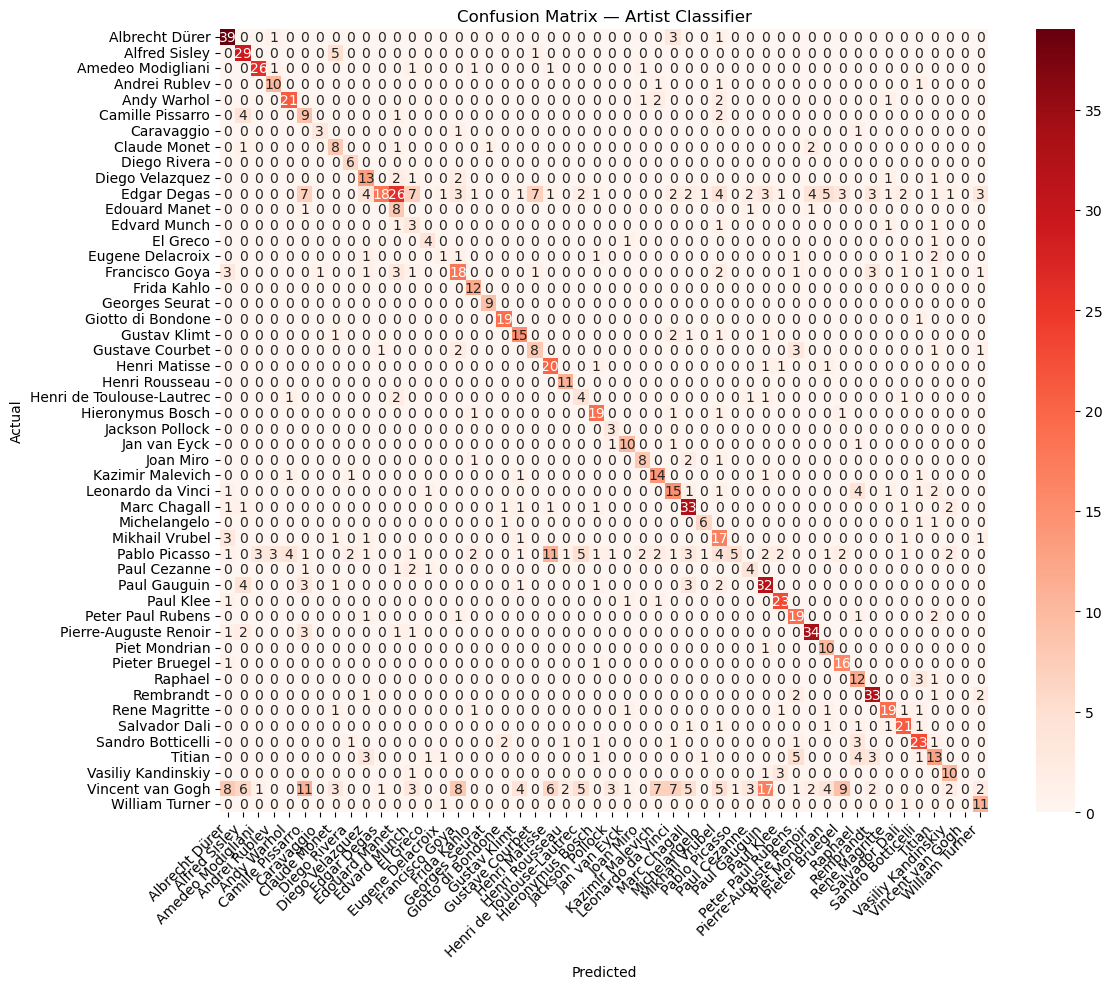

In [38]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=artist_names,
    yticklabels=artist_names,
    cmap="Reds"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Artist Classifier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Saving Results

Update the names of artifacts to not overwrite the style model.

In [42]:
# Save model architecture config so you can rebuild it identically
model_config = {
    "num_classes": num_classes,
    "backbone": "efficientnet_b0",
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
}

with open("artifacts/best_artist_model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

# Save training history
with open("artifacts/best_artist_training_history.json", "w") as f:
    json.dump(history, f, indent=2)

# Save artist label maps
with open("data/artist_labels.json", "w") as f:
    json.dump(artist_labels, f, indent=2)

print("Saved:")


Saved:


In [43]:
# Confirm the saved model loads cleanly
test_model = ArtistClassifier(num_classes=num_classes).to(device)
test_model.load_state_dict(torch.load("artifacts/best_artist_model.pt", map_location=device))
test_model.eval()
print(f"✓ Model loads cleanly — {num_classes} classes")
print(f"✓ Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")

✓ Model loads cleanly — 50 classes
✓ Best epoch: 8, Best val loss: 1.0987


In [44]:
# Resume cell:  run this at the start of future sessions
with open("data/artist_labels.json", "r") as f:
    artist_labels = json.load(f)
idx_to_artist = {i: s for s, i in artist_labels.items()}

with open("artifacts/best_artist_model_config.json", "r") as f:
    model_config = json.load(f)

with open("artifacts/best_artist_training_history.json", "r") as f:
    history = json.load(f)

device = torch.device("mps")
model = ArtistClassifier(num_classes=model_config["num_classes"]).to(device)
model.load_state_dict(torch.load("artifacts/best_artist_model.pt", map_location=device))
model.eval()

print(f" Resumed — {model_config['num_classes']} classes, best epoch {model_config['best_epoch']}")

 Resumed — 50 classes, best epoch 8
